# PCA90 and Manifold Alignment: An Executed Synthetic Example

**Synthetic demonstration only.** All signals and MU identities in this notebook are generated
from equations and a fixed random seed. No participant recordings, real MU tracking results,
private data-derived parameters, or source paths are used or embedded.

This is a completed, rerunnable example of the seven modules in
`PCA90_Alignment_Controls.ipynb`. Tables and all six comparison images are already displayed.
The module numbers and analysis operations match the input-based notebook; Modules 1–2 generate
synthetic inputs in memory instead of reading MAT recordings and CSV dictionaries.

| Module | Example output |
| --- | --- |
| 1. Select the data and comparison | Reproducible synthetic configuration; no file inputs |
| 2. Prepare tracked-MU matrices | Dictionary-based assembly and a 20-condition PCA90 table |
| 3. Define visual conventions | Shared plotting and global CCA functions |
| 4. Before and after CCA | Canonical correlation table and 2D/3D images |
| 5. Temporal-block control | Unshuffled/shuffled correlation table and 2D/3D images |
| 6. Whole-space task-mismatch control | Task correspondence table, correlation table and 2D/3D images |
| 7. Complete the analysis | Inline completion; separate exports disabled by default |

All values are calculated by the cells below; none are copied from a research dataset.
These simplified generated signals illustrate software behavior, not physiological findings.

## 1. Select the data and comparison

Two fictional datasets, two fictional sites and five illustrative angles produce 20 conditions.
The selected comparison is **Demo01 / SiteA / 0° → Demo01 / SiteA / 10°**.
These labels are invented identifiers, not renamed participants.

Run from top to bottom without entering any paths. All inputs are generated in memory.
`DATA_ROOT`, `DICTIONARY_ROOT` and `OUTPUT_DIR` remain blank. Separate file exports remain off.

### Synthetic input design

Smooth oscillatory population signals drive artificial MU discharge events. A cumulative-rate
threshold generates the events; this deliberately regular toy model is not a fitted model of
human motor-unit firing. The sample rate is 256 Hz. Three tasks have slightly different durations,
and condition lengths vary, so the native-sample cropping step is exercised.

Each condition contains 6 identities shared across all three tasks and 6 additional identities
specific to each task. Each recording has 12 MU rows; the pooled feature matrix has 24 MU columns,
rather than treating the 36 appearances as separate MUs. Task-specific columns make the three
task groups visible in the pooled space. The row order is independently permuted
for each recording. An in-memory tracking dictionary maps each appearance back to its identity.

**The dictionary is known from the generator.** It does not demonstrate an MU tracking algorithm.
No recording files or individual MU traces are displayed or exported by default.

In [1]:
from pathlib import Path
import os, json
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(min(4, os.cpu_count() or 1)))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, HTML, Markdown
from types import SimpleNamespace
from scipy import signal, ndimage
from scipy.linalg import svd
TASKS = ('index', 'middle', 'index-middle')
RIDGE = 1e-6

DATA_ROOT = ""         # Unused in this self-contained synthetic example.
DICTIONARY_ROOT = ""   # Unused: tracking dictionaries are generated in memory.
SAVE_OUTPUTS = False   # False: display results inline without writing output files.
OUTPUT_DIR = ""        # Required only when SAVE_OUTPUTS is True; no default output folder.
SUBJECTS = ('Demo01', 'Demo02')
ANGLES = (0, 10, 20, 30, 40)
SOURCE = ('Demo01', 'SiteA', 0)
TARGET = ('Demo01', 'SiteA', 10)
SEED = 1
DISPLAY_STRIDE = 4  # Display only; PCA and CCA use every native sample.
COLORS = ['#0072B2', '#D55E00', '#009E73']
TASK_LABELS = ['Index', 'Middle', 'Index–middle']
plt.rcParams.update({'figure.dpi': 110, 'font.family':'DejaVu Sans',
                     'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False})

def require_input_directory(value, setting):
    if not str(value).strip():
        raise ValueError(f'Please fill in {setting}. See Required input files above.')
    path = Path(value).expanduser()
    if not path.is_dir():
        raise ValueError(f'{setting} must point to an existing input directory.')
    return path

EXPORT_ROOT = None
if SAVE_OUTPUTS:
    if not str(OUTPUT_DIR).strip():
        raise ValueError('Fill in OUTPUT_DIR to enable exports, or set SAVE_OUTPUTS = False.')
    EXPORT_ROOT = Path(OUTPUT_DIR).expanduser()
    EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

def export_table(table, filename):
    if SAVE_OUTPUTS:
        table.to_csv(EXPORT_ROOT/filename, index=False)
DEMO_SEED = 20260921
FS = 256.0
SITES = ('SiteA', 'SiteB')
# Preserve the complete canvas so 3D axis labels are not cropped.
get_ipython().run_line_magic("config", "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

## 2. Prepare the tracked-MU activity matrices

**Synthetic discharge events → binary spike trains → 400 ms periodic Hann smoothing →
0.75 Hz high-pass filtering → per-MU min–max normalization → dictionary-based MU columns → pooled PCA.**

The numerical preprocessing, PCA, CCA and shuffle functions use the same calculations as the
input-based notebook. The dictionary assembly below places each shared identity in one column
before stacking all three tasks. A task-specific identity has zeros in the other task blocks.

Each task is cropped from its start to that task's minimum native length across the synthetic cohort.
There is no resampling or downsampling before PCA. Each pooled condition is mean-centered; the table
reports the minimum dimension for 90% variance and the retained alignment dimension, which is at least 3.

In [2]:
def binary_spikes(recording):
    spikes = np.zeros((recording.n_samples, recording.n_mu))
    for mu, indices in enumerate(recording.times):
        spikes[indices, mu] = 1
    return spikes

def preprocess(recording, mode='tracked_hann'):
    spikes = binary_spikes(recording)
    fs = recording.fs
    if mode == 'legacy_isomap_gaussian':
        smooth = ndimage.gaussian_filter1d(spikes, sigma=max(1.0, 0.1 * fs), axis=0, mode='constant', truncate=3.0) * fs
        return dict(spikes=spikes, smooth=smooth, highpass=smooth.copy(), rate=smooth.copy())
    if mode != 'tracked_hann':
        raise ValueError(mode)
    length = max(3, int(np.floor(0.4 * fs + 0.5)))
    kernel = signal.windows.hann(length, sym=False)
    kernel /= kernel.sum()
    full = signal.convolve(spikes, kernel[:, None], mode='full', method='direct')
    smooth = full[length // 2:length // 2 + recording.n_samples] * fs
    b, a = signal.butter(2, 0.75 / (fs / 2), btype='highpass')
    padlen = 3 * (max(len(a), len(b)) - 1)
    highpass = signal.filtfilt(b, a, smooth, axis=0, padtype='odd', padlen=padlen)
    span = np.ptp(highpass, axis=0)
    span[span == 0] = 1
    rate = (highpass - highpass.min(axis=0)) / span
    if not np.isfinite(rate).all():
        raise ValueError(f'Non-finite rates in {recording.path}')
    return dict(spikes=spikes, smooth=smooth, highpass=highpass, rate=rate)

def pca_fit(F):
    F = np.asarray(F, dtype=float)
    mean = F.mean(axis=0)
    u, s, vt = svd(F - mean, full_matrices=False)
    if s[0] <= 0:
        raise ValueError('PCA needs nonconstant data')
    explained = 100 * s ** 2 / np.sum(s ** 2)
    k90 = min(len(s), int(np.searchsorted(np.cumsum(explained), 90) + 1))
    dims = max(3, k90)
    scores = u * s
    X = np.pad(scores[:, :dims], ((0, 0), (0, max(0, dims - scores.shape[1]))))
    return dict(X=X, mean=mean, coeff=vt.T, explained=explained, k90=k90)

def invsqrt(S):
    d, v = np.linalg.eigh((S + S.T) / 2)
    return v * (1 / np.sqrt(np.maximum(d, np.finfo(float).eps))) @ v.T

def cca_fit(source, target, ridge=RIDGE):
    if source.shape[0] != target.shape[0]:
        raise ValueError('CCA requires paired rows')
    sm, tm = (source.mean(axis=0), target.mean(axis=0))
    S, T = (source - sm, target - tm)
    n = max(1, len(S) - 1)
    ws = invsqrt(S.T @ S / n + ridge * np.eye(S.shape[1]))
    wt = invsqrt(T.T @ T / n + ridge * np.eye(T.shape[1]))
    u, r, vt = svd(wt @ (T.T @ S / n) @ ws, full_matrices=False)
    A, B = (wt @ u, ws @ vt.T)
    source_can = S @ B
    cm, sd = (source_can.mean(axis=0), source_can.std(axis=0, ddof=1))
    sd[sd == 0] = 1
    return dict(A=A, B=B, r=np.clip(r, 0, 1), sm=sm, tm=tm, cm=cm, sd=sd)

def cca_transform(mapping, source, target):
    m = mapping
    source_can = ((source - m['sm']) @ m['B'] - m['cm']) / m['sd']
    target_can = ((target - m['tm']) @ m['A'] * m['r'] - m['cm']) / m['sd']
    return (source_can, target_can)

def block_shuffle(F, y, rng, fraction=0.1):
    out, records = (F.copy(), [])
    for c in np.unique(y):
        rows = np.flatnonzero(y == c)
        size = max(1, int(np.floor(len(rows) * fraction)))
        n = len(rows) // size
        perm = rng.permutation(n)
        take = np.concatenate([rows[p * size:(p + 1) * size] for p in perm])
        out[rows[:n * size]] = F[take]
        records.append(dict(task=TASKS[c - 1], block_samples=size, n_blocks=n, tail_samples=len(rows) - n * size, permutation=perm.tolist()))
    return (out, records)

def generate_condition(key, condition_index):
    local_rng = np.random.default_rng(DEMO_SEED + condition_index)
    identities = [f'SyntheticMU{i + 1:02d}' for i in range(6)]
    all_ids = identities + [f'SyntheticPrivate{i + 1:02d}' for i in range(18)]
    weights = local_rng.normal(size=(len(all_ids), 3))
    weights /= np.linalg.norm(weights, axis=1, keepdims=True)
    dictionaries, recordings = [], {}
    for task_index, task in enumerate(TASKS):
        n_samples = int(FS * [6.2, 6.0, 6.4][task_index]) + 9 * (condition_index % 4)
        t = np.arange(n_samples) / FS
        phase = 2 * np.pi * (1.03 * t + 0.028 * t ** 2)
        offset = 2 * np.pi * task_index / 3
        latent = np.column_stack([
            np.sin(phase + offset),
            np.cos(phase + offset),
            0.6 * np.sin(1.63 * phase + 0.8 * task_index),
        ])
        private_rows = np.arange(6 + 6 * task_index, 12 + 6 * task_index)
        present = local_rng.permutation(np.r_[np.arange(6), private_rows])
        rates = np.clip(28 + 14 * latent @ weights[present].T, 6, 55)
        phase_count = np.cumsum(rates / FS, axis=0) + local_rng.uniform(size=len(present))
        spikes = np.diff(np.floor(phase_count), axis=0, prepend=np.floor(phase_count[:1])) > 0
        times = [np.flatnonzero(spikes[:, mu]) for mu in range(len(present))]
        recordings[task] = SimpleNamespace(
            path='synthetic-in-memory', fs=FS, n_samples=n_samples, n_mu=len(present), times=times)
        dictionaries.extend({'unique_mu':all_ids[identity], 'task':task, 'mu_index0':row}
                            for row, identity in enumerate(present))
    return {'key':key, 'recordings':recordings, 'dictionary':pd.DataFrame(dictionaries)}

def assemble_condition(condition, crop_counts):
    dictionary, recordings = condition['dictionary'], condition['recordings']
    assert not dictionary.duplicated(['unique_mu', 'task']).any()
    assert not dictionary.duplicated(['task', 'mu_index0']).any()
    identities = list(pd.unique(dictionary.unique_mu))
    blocks, labels = [], []
    for task_index, task in enumerate(TASKS, 1):
        rate = preprocess(recordings[task])['rate'][:crop_counts[task]]
        block = np.zeros((len(rate), len(identities)))
        for row in dictionary[dictionary.task == task].itertuples():
            block[:, identities.index(row.unique_mu)] = rate[:, int(row.mu_index0)]
        blocks.append(block)
        labels.append(np.full(len(rate), task_index, dtype=int))
    return {'F':np.vstack(blocks), 'y':np.concatenate(labels)}

keys = [(subject, site, angle) for subject in SUBJECTS for site in SITES for angle in ANGLES]
conditions = [generate_condition(key, i) for i, key in enumerate(keys)]
crop_counts = {task:min(c['recordings'][task].n_samples for c in conditions) for task in TASKS}
selected, pca_rows = {}, []
for condition in conditions:
    key = condition['key']
    feature = assemble_condition(condition, crop_counts)
    model = pca_fit(feature['F'])
    assert feature['F'].shape[1] == 24
    pca_rows.append({
        'Dataset':key[0], 'Site':key[1], 'Angle (deg)':key[2],
        'Unique synthetic MUs':feature['F'].shape[1],
        'PCs for 90% variance':model['k90'],
        'Variance explained (%)':np.sum(model['explained'][:model['k90']]),
        'Dimensions retained for alignment':model['X'].shape[1],
    })
    if key in [SOURCE, TARGET]:
        selected[key] = {**feature, 'pca':model}
source, target = selected[SOURCE], selected[TARGET]
assert np.array_equal(source['y'], target['y'])
y = source['y']
pca_table = pd.DataFrame(pca_rows)
display(pca_table.style.hide(axis='index').format({'Variance explained (%)':'{:.2f}'}))
export_table(pca_table, 'pca90_dimensionality.csv')
display(Markdown(
    f"**Example reading:** across these 20 synthetic conditions, "
    f"{pca_table['PCs for 90% variance'].min()}–{pca_table['PCs for 90% variance'].max()} PCs "
    "explain at least 90% of the variance. Each PCA uses 24 unique synthetic MU columns."))

Dataset,Site,Angle (deg),Unique synthetic MUs,PCs for 90% variance,Variance explained (%),Dimensions retained for alignment
Demo01,SiteA,0,24,6,91.16,6
Demo01,SiteA,10,24,6,93.08,6
Demo01,SiteA,20,24,6,91.57,6
Demo01,SiteA,30,24,6,93.52,6
Demo01,SiteA,40,24,6,92.82,6
Demo01,SiteB,0,24,6,91.88,6
Demo01,SiteB,10,24,5,91.87,5
Demo01,SiteB,20,24,6,91.22,6
Demo01,SiteB,30,24,6,91.11,6
Demo01,SiteB,40,24,6,91.46,6


**Example reading:** across these 20 synthetic conditions, 5–6 PCs explain at least 90% of the variance. Each PCA uses 24 unique synthetic MU columns.

## 3. Define the visual conventions

**Color identifies the task. Solid lines show the source; dashed lines show the target.**
Open circles mark the beginning of a task trajectory. The images show the first two or three modes;
CCA is fitted using all retained dimensions.

Before alignment, source and target have independent PCA coordinate systems.
After alignment, target canonical scores are weighted by their canonical correlations and scaled using the source,
using the same convention as the input-based notebook.

The observed and shuffled CCA fits each define their own axes. Compare source–target overlap **within** a panel;
do not interpret a rotation between panels as a change in the underlying activity by itself.

In [3]:
def condition_label(key):
    return f'{key[0]} / {key[1]} / {key[2]}°'

def alignment_metrics(label, mapping, S, T):
    r = np.asarray(mapping['r'])
    row = {'Analysis':label, 'Paired samples':len(S),
           'Source PCs':S.shape[1], 'Target PCs':T.shape[1], 'CCA modes':len(r)}
    row.update({f'r{mode+1}':float(value) for mode,value in enumerate(r)})
    row['Mean top-3 r'] = float(np.mean(r[:3]))
    return row

def display_metrics(table):
    formats = {column:'{:.4f}' for column in table.columns
               if column.startswith('r') or column == 'Mean top-3 r'}
    display(table.style.hide(axis='index').format(formats, na_rep='—'))

def padded(values):
    return np.pad(values, ((0,0), (0,max(0,3-values.shape[1]))))

def limits_for(arrays, dims):
    values = np.vstack([padded(a)[:, :dims] for a in arrays])
    lo, hi = values.min(axis=0), values.max(axis=0)
    margin = np.maximum(hi-lo, 1e-3)*.08
    return list(zip(lo-margin, hi+margin))

def draw_trajectories(ax, S, T, labels, dims, aligned=False, limits=None, task_ids=(1,2,3)):
    S, T = padded(S), padded(T)
    for task_id in task_ids:
        idx = np.flatnonzero(labels == task_id)
        draw = np.unique(np.r_[idx[::DISPLAY_STRIDE], idx[-1]])
        for values, style in [(S, '-'), (T, '--')]:
            args = [values[draw,j] for j in range(dims)]
            ax.plot(*args, color=COLORS[task_id-1], linestyle=style, linewidth=1.15, alpha=.9)
            start = [values[idx[0],j:j+1] for j in range(dims)]
            ax.plot(*start, marker='o', markersize=4, markerfacecolor='white',
                    markeredgecolor=COLORS[task_id-1], linestyle='None')
    prefix = 'Canonical mode' if aligned else 'PC'
    ax.set_xlabel(f'{prefix} 1')
    ax.set_ylabel(f'{prefix} 2')
    if dims == 3:
        short = 'CC' if aligned else 'PC'
        ax.set_xlabel(f'{short} 1', fontsize=9, labelpad=2)
        ax.set_ylabel(f'{short} 2', fontsize=9, labelpad=2)
        ax.set_zlabel(f'{short} 3', fontsize=9, labelpad=10)
        ax.view_init(elev=23, azim=-55)
        ax.set_box_aspect((1,1,1), zoom=.82)
        from matplotlib.ticker import MaxNLocator
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            axis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(labelsize=8)
    else:
        ax.set_aspect('equal', adjustable='box')
    if limits is not None:
        ax.set_xlim(limits[0]); ax.set_ylim(limits[1])
        if dims == 3: ax.set_zlim(limits[2])

def add_legend(fig):
    handles = [Line2D([0],[0], color=c, lw=2, label=t) for c,t in zip(COLORS,TASK_LABELS)]
    handles += [Line2D([0],[0], color='#333333', lw=1.4, label='Source', linestyle='-'),
                Line2D([0],[0], color='#333333', lw=1.4, label='Target', linestyle='--')]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False,
               bbox_to_anchor=(.5,.01), fontsize=10)

def save_image(fig, name):
    if SAVE_OUTPUTS:
        fig.savefig(EXPORT_ROOT/f'{name}.png', dpi=200, bbox_inches=None)
    plt.show()

Xs, Xt = source['pca']['X'], target['pca']['X']
observed_mapping = cca_fit(Xs, Xt)
observed_source, observed_target = cca_transform(observed_mapping, Xs, Xt)

## 4. Observed trajectories: before and after CCA

Read each row from left to right. The left panel shows independent PCA trajectories;
the right panel shows the source and target after CCA alignment.

The accompanying table reports **r1, r2, r3, ...** for every fitted canonical mode and
**Mean top-3 r**, the top-three summary. It also lists the paired sample count,
source/target PCA dimensions and the number of canonical modes.
These r values are the regularized CCA singular values returned by the CCA function;
they can differ slightly from direct Pearson correlations of the displayed canonical scores because of regularization.
All metrics use the full paired data, not just the points subsampled for display. They describe the fitted alignment,
not held-out performance. PCA explained variance and canonical correlation are different quantities.

Here, "observed" means the unshuffled synthetic realization; no experimental observations are used.

Analysis,Paired samples,Source PCs,Target PCs,CCA modes,r1,r2,r3,r4,r5,r6,Mean top-3 r
Unshuffled synthetic,4761,6,6,6,0.9986,0.9911,0.9867,0.9775,0.9547,0.2511,0.9921


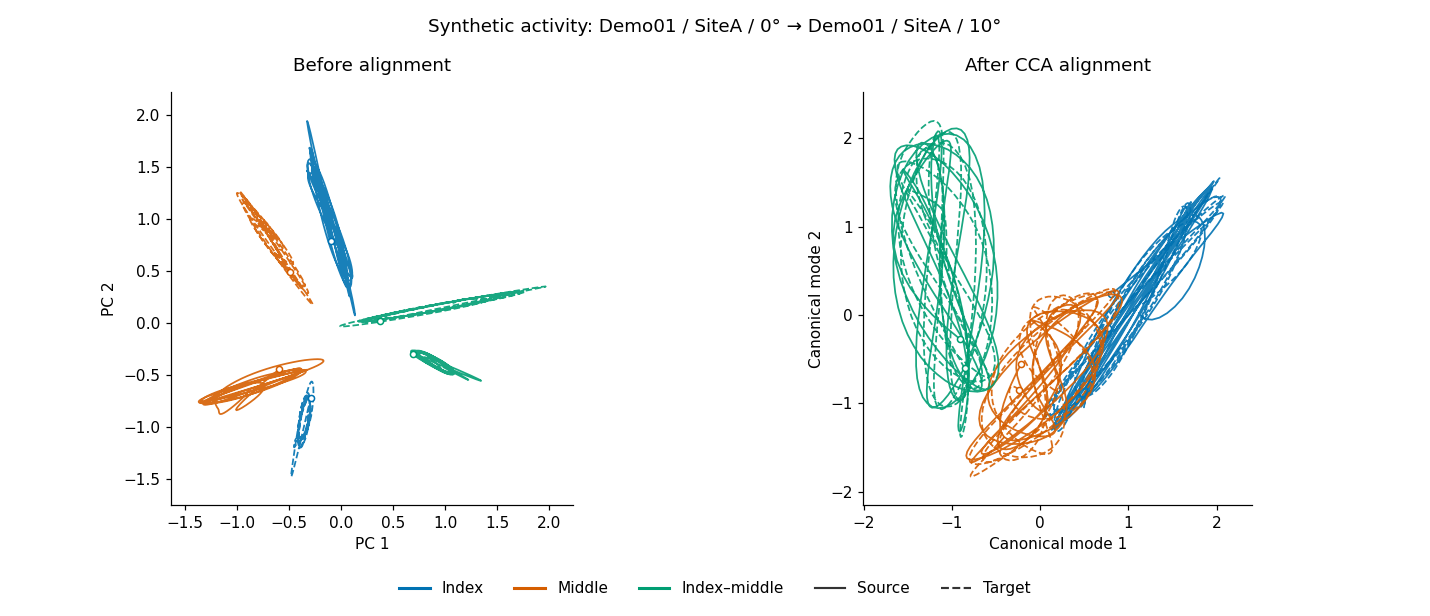

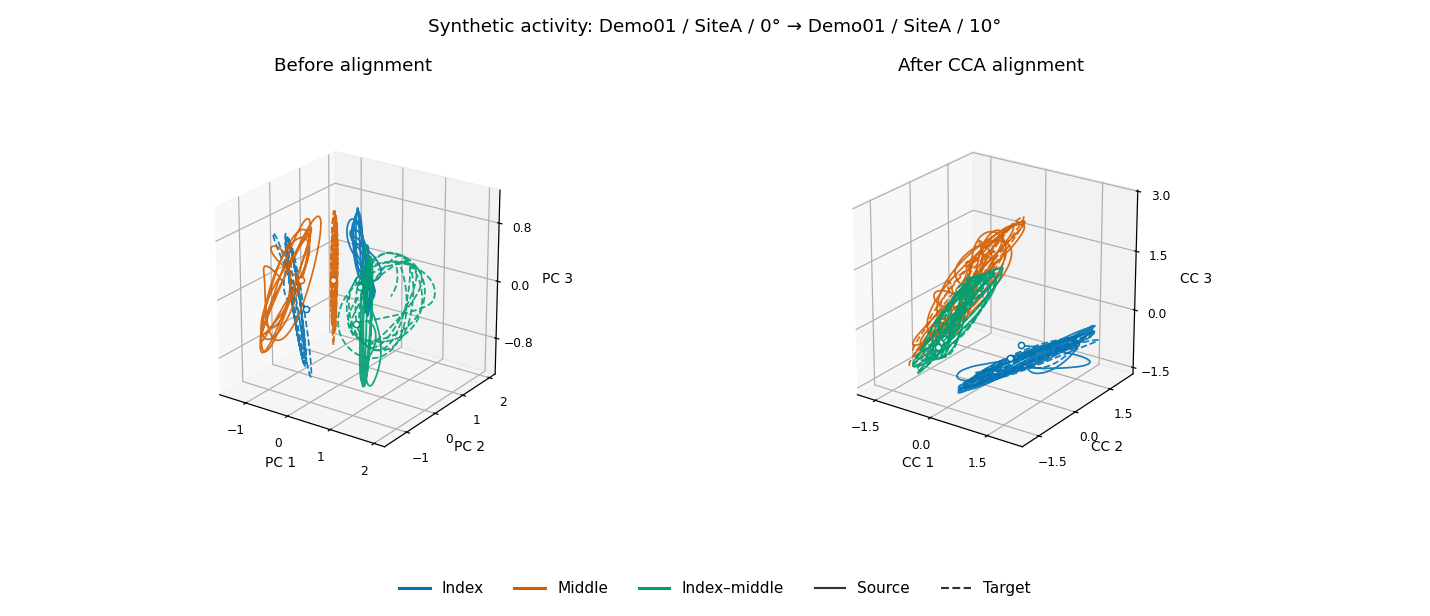

**Example reading:** the unshuffled global fit has mean top-3 r = 0.9921. The right panels show the same complete three-task populations after a single global alignment.

In [4]:
observed_metrics = pd.DataFrame([alignment_metrics('Unshuffled synthetic', observed_mapping, Xs, Xt)])
display_metrics(observed_metrics)
export_table(observed_metrics, 'observed_alignment_metrics.csv')

for dims in [2,3]:
    fig = plt.figure(figsize=(13,5.6))
    fig.suptitle(f'Synthetic activity: {condition_label(SOURCE)} → {condition_label(TARGET)}', y=.97)
    for col,S,T,aligned,title in [(1,Xs,Xt,False,'Before alignment'),
                                 (2,observed_source,observed_target,True,'After CCA alignment')]:
        ax = fig.add_subplot(1,2,col,projection='3d' if dims==3 else None)
        draw_trajectories(ax,S,T,y,dims,aligned=aligned,limits=limits_for([S,T],dims))
        ax.set_title(title, pad=14)
    fig.subplots_adjust(left=.07,right=(.87 if dims==3 else .93),bottom=.18,top=.85,wspace=.26)
    add_legend(fig)
    save_image(fig,f'observed_before_after_{dims}d')

display(Markdown(
    f"**Example reading:** the unshuffled global fit has mean top-3 r = "
    f"{observed_mapping['r'][:3].mean():.4f}. "
    "The right panels show the same complete three-task populations after a single global alignment."))


## 5. Temporal-block control: observed versus shuffled activity

Each task is divided into non-overlapping blocks of length `floor(10% × task samples)`.
All MU columns in a task share one block permutation. Different tasks, source and target receive independent
permutations; any incomplete tail remains in place. PCA and CCA are then recomputed.

This control preserves task labels, task means, missing-MU blocks and the within-task population sample distribution.
It disrupts long-range temporal correspondence. Consequently, visible task clusters can remain after shuffling.
Line jumps in the control images represent transitions between rearranged time blocks.

The **top row is observed data** and the **bottom row is the shuffled control**.
Columns show trajectories before and after alignment. Limits are shared within each column.
PCA loading signs are matched to their observed counterparts only to remove arbitrary SVD sign flips.

The table below compares the **observed fit** with the **same shuffled realization shown in the images**.
The shuffled row reports correlations after refitting PCA and CCA. This is one realization with the configured seed,
not an average across repetitions or a significance test.

Analysis,Paired samples,Source PCs,Target PCs,CCA modes,r1,r2,r3,r4,r5,r6,Mean top-3 r
Unshuffled synthetic,4761,6,6,6,0.9986,0.9911,0.9867,0.9775,0.9547,0.2511,0.9921
Temporal-block shuffle,4761,6,6,6,0.9305,0.9219,0.3338,0.2092,0.1688,0.0983,0.7287


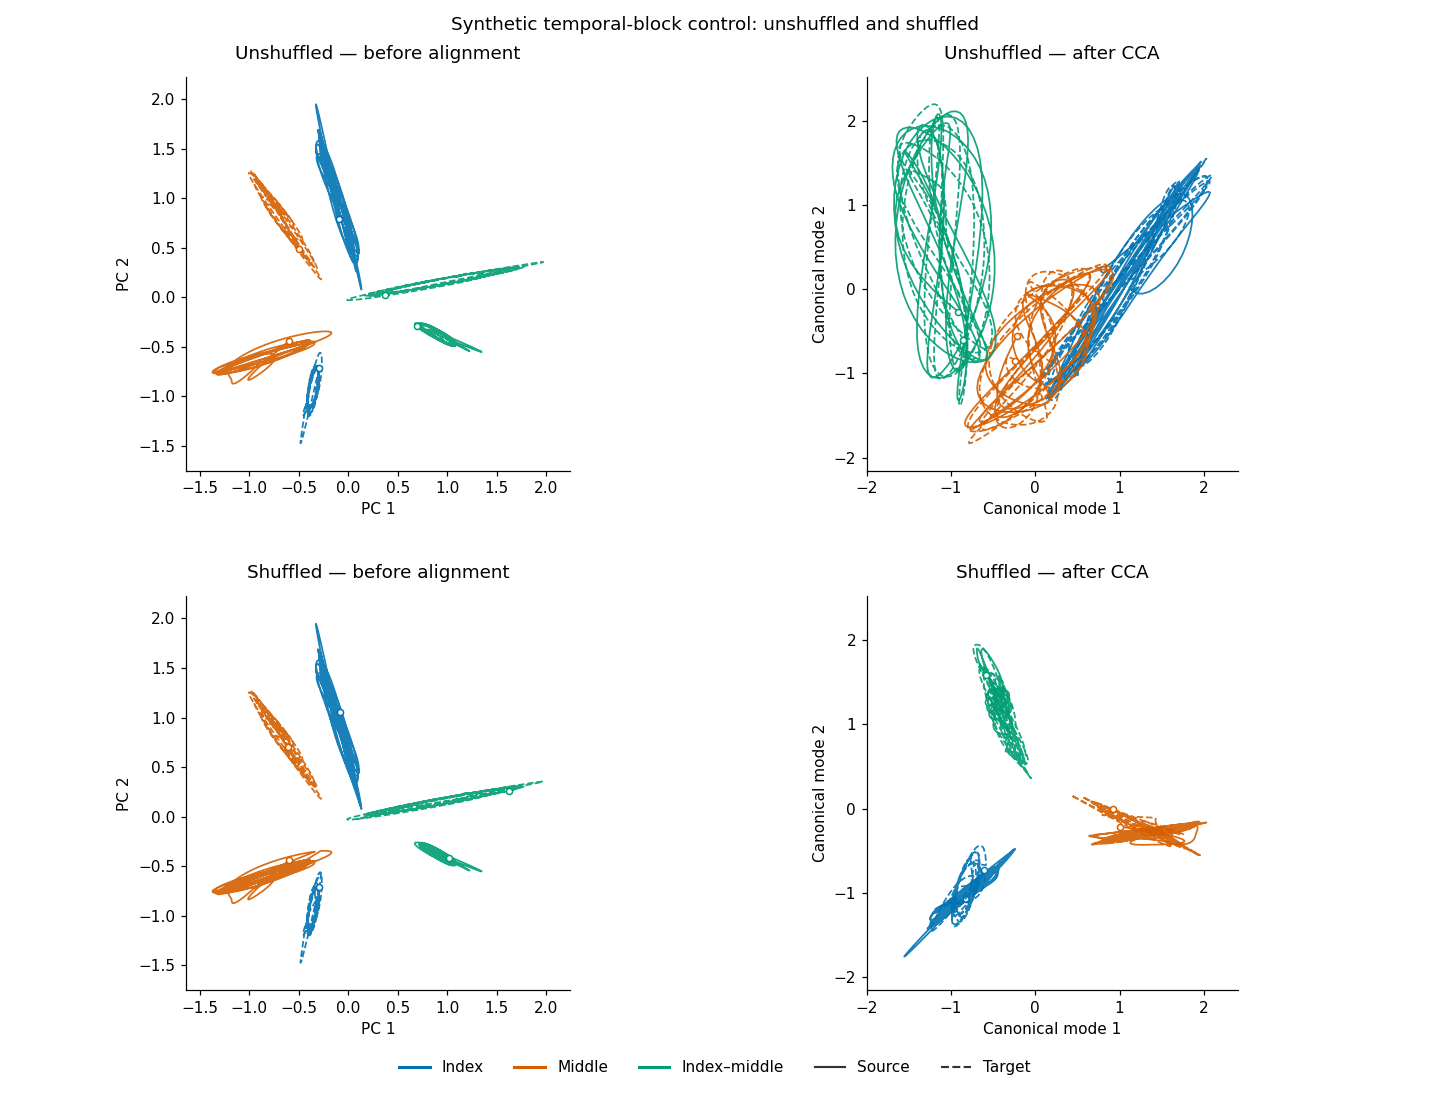

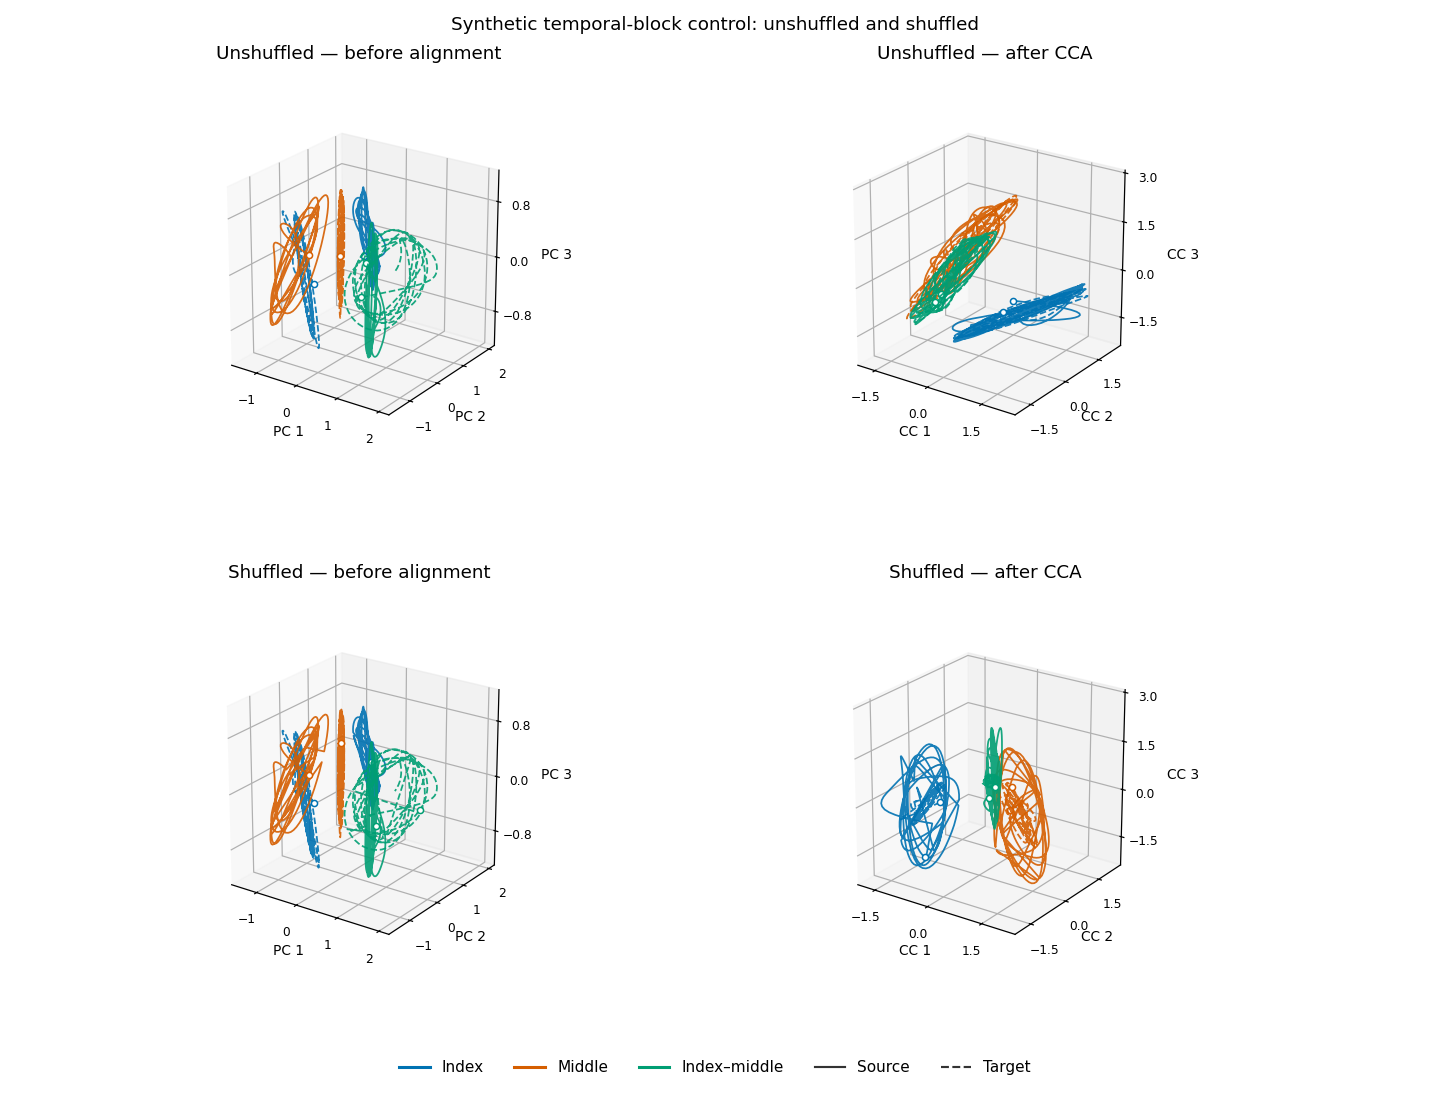

**Example reading:** mean top-3 r is 0.9921 before shuffling and 0.7287 for this shuffled realization. The displayed control refits PCA and CCA after permuting temporal blocks; this is one seed, not a statistical test.

In [5]:
rng = np.random.default_rng(SEED)
Fs_control, source_permutations = block_shuffle(source['F'], y, rng)
Ft_control, target_permutations = block_shuffle(target['F'], y, rng)
sp_control, tp_control = pca_fit(Fs_control), pca_fit(Ft_control)
for control_model, observed_model in [(sp_control,source['pca']), (tp_control,target['pca'])]:
    n = min(control_model['X'].shape[1], control_model['coeff'].shape[1])
    signs = np.sign(np.sum(control_model['coeff'][:,:n]*observed_model['coeff'][:,:n],axis=0))
    signs[signs==0] = 1
    control_model['X'][:,:n] *= signs
Xsc, Xtc = sp_control['X'], tp_control['X']
control_mapping = cca_fit(Xsc, Xtc)
control_source, control_target = cca_transform(control_mapping, Xsc, Xtc)

alignment_control_metrics = pd.DataFrame([
    alignment_metrics('Unshuffled synthetic', observed_mapping, Xs, Xt),
    alignment_metrics('Temporal-block shuffle', control_mapping, Xsc, Xtc),
])
display_metrics(alignment_control_metrics)
export_table(alignment_control_metrics, 'observed_vs_shuffle_alignment_metrics.csv')

for dims in [2,3]:
    fig = plt.figure(figsize=(13,10))
    fig.suptitle('Synthetic temporal-block control: unshuffled and shuffled', y=.985)
    before_limits = limits_for([Xs,Xt,Xsc,Xtc],dims)
    after_limits = limits_for([observed_source,observed_target,control_source,control_target],dims)
    panels = [
        (1,Xs,Xt,False,'Unshuffled — before alignment',before_limits),
        (2,observed_source,observed_target,True,'Unshuffled — after CCA',after_limits),
        (3,Xsc,Xtc,False,'Shuffled — before alignment',before_limits),
        (4,control_source,control_target,True,'Shuffled — after CCA',after_limits),
    ]
    for panel,S,T,aligned,title,limits in panels:
        ax = fig.add_subplot(2,2,panel,projection='3d' if dims==3 else None)
        draw_trajectories(ax,S,T,y,dims,aligned=aligned,limits=limits)
        ax.set_title(title,pad=12)
    fig.subplots_adjust(left=.08,right=(.86 if dims==3 else .92),bottom=.1,top=.93,wspace=.28,hspace=.32)
    add_legend(fig)
    save_image(fig,f'temporal_control_before_after_{dims}d')

display(Markdown(
    f"**Example reading:** mean top-3 r is {observed_mapping['r'][:3].mean():.4f} "
    f"before shuffling and {control_mapping['r'][:3].mean():.4f} for this shuffled realization. "
    "The displayed control refits PCA and CCA after permuting temporal blocks; this is one seed, not a statistical test."))


## 6. Whole-space task-mismatch control

**Keep the entire pooled latent space. Change only the task correspondence used to fit CCA.**
The original pooled PCA bases and retained dimensions stay fixed. Every CCA fit includes all three tasks together.
Each fit produces one source projection and one target projection; each dataset's projection is shared by all its
task trajectories. No task-specific CCA projections are fitted.

For example, one incorrect correspondence is:

**Source Index ↔ Target Middle; Source Middle ↔ Target Index–middle;
Source Index–middle ↔ Target Index.**

Both possible cyclic permutations that mismatch all three tasks are shown. The mapping table specifies the
target task assigned to each source task during fitting.
After fitting, apply the global projections to the original, complete source and target trajectories.
**Plot colors always retain the true task identities.** Thus a blue source trajectory overlapping an orange target
trajectory illustrates wrong-task alignment; the target is never recolored to hide the mismatch.

The native task lengths differ. To isolate task correspondence from length differences, use the first
`min(task lengths)` samples of each task for all three CCA fits in this section: the correct-correspondence baseline
and both mismatched controls. This selects the same sample sets for every fit, merely reordered on the target side.
The PCA bases remain those fitted to the full pooled datasets, and the plots show **all original rows** after projection.
Consequently, this section's correct baseline uses slightly fewer fitting rows than Section 4; compare each control
against the matched-length correct baseline in this section.

The canonical correlations in the table are calculated under the correspondence used to fit that model.
A high value for an incorrect mapping does not mean true task identities have been aligned correctly.
This control evaluates a single global alignment under each pooled task correspondence.

Analysis,Source Index paired with,Source Middle paired with,Source Index–middle paired with
Correct correspondence,Index,Middle,Index–middle
Wrong correspondence A,Middle,Index–middle,Index
Wrong correspondence B,Index–middle,Index,Middle


Analysis,Paired samples,Source PCs,Target PCs,CCA modes,r1,r2,r3,r4,r5,r6,Mean top-3 r
Correct correspondence,4608,6,6,6,0.9986,0.9916,0.9867,0.9797,0.9564,0.2545,0.9923
Wrong correspondence A,4608,6,6,6,0.9963,0.9774,0.9572,0.8920,0.6750,0.4034,0.9770
Wrong correspondence B,4608,6,6,6,0.9947,0.9827,0.9747,0.9454,0.6046,0.3516,0.9840


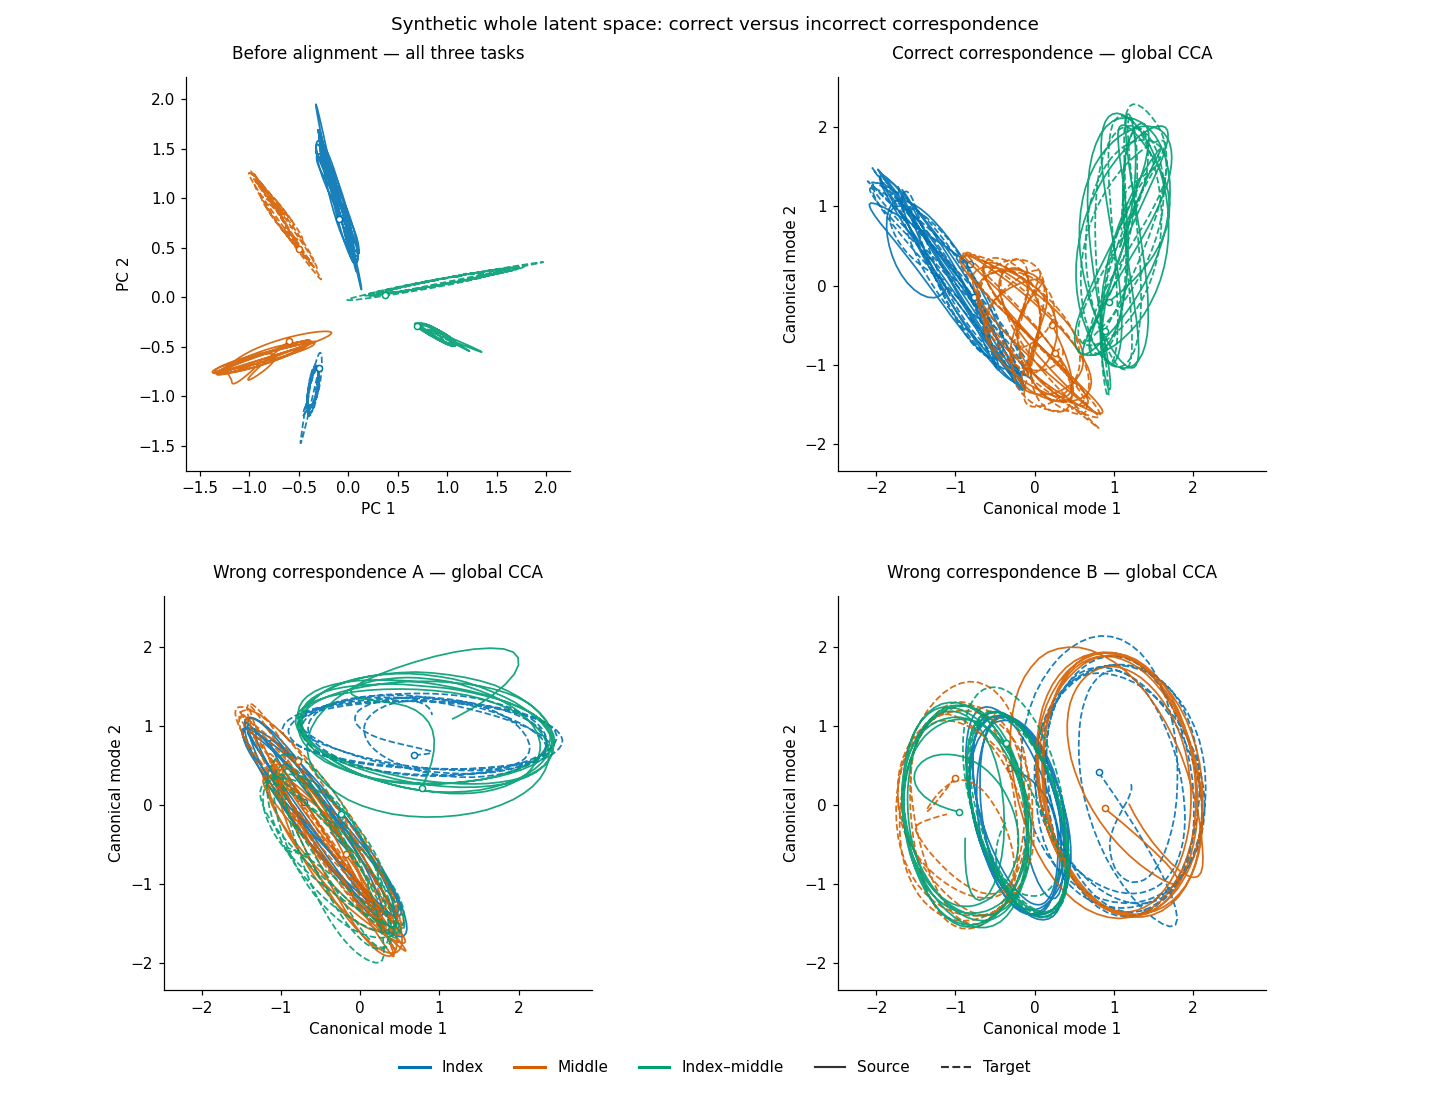

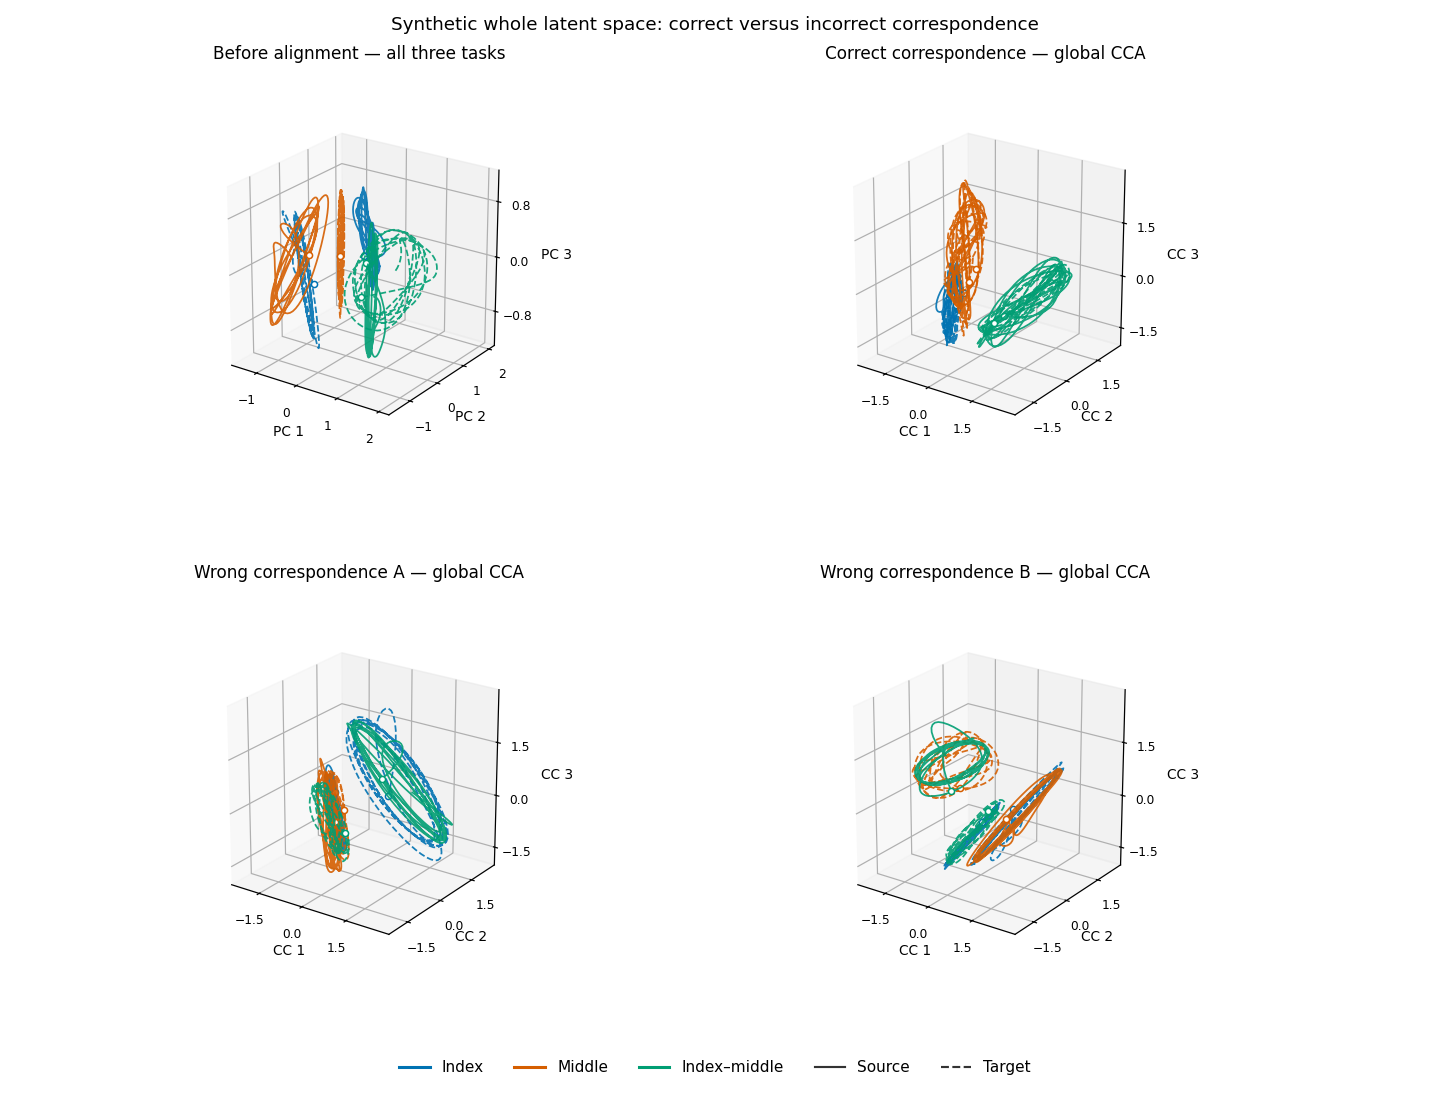

**Example reading:** compare each wrong-correspondence row against the correct-correspondence row in this table. All three global fits use the same sample sets and the same pooled PCA spaces. A high r under a wrong pairing can coexist with overlap between different true task colors; it is not evidence of correct task correspondence.

In [6]:
def pooled_pairing_indices(labels, target_order):
    # One row pairing for a single global CCA fit spanning all three tasks.
    if sorted(target_order) != [1,2,3]:
        raise ValueError('Target task order must be a permutation of (1, 2, 3).')
    rows_by_task = {c:np.flatnonzero(labels==c) for c in [1,2,3]}
    count = min(len(rows) for rows in rows_by_task.values())
    source_rows = np.concatenate([rows_by_task[c][:count] for c in [1,2,3]])
    target_rows = np.concatenate([rows_by_task[c][:count] for c in target_order])
    # Every fit uses the same samples; only their target-side correspondence changes.
    assert np.array_equal(np.sort(source_rows), np.sort(target_rows))
    return source_rows, target_rows, count

correspondences = [
    ('Correct correspondence', (1,2,3)),
    ('Wrong correspondence A', (2,3,1)),
    ('Wrong correspondence B', (3,1,2)),
]
pairing_table = pd.DataFrame([
    {'Analysis':label, **{f'Source {TASK_LABELS[i]} paired with':TASK_LABELS[order[i]-1]
                         for i in range(3)}}
    for label,order in correspondences
])
display(pairing_table.style.hide(axis='index'))
export_table(pairing_table, 'whole_space_task_correspondences.csv')

whole_space_fits = []
whole_space_metric_rows = []
for label,order in correspondences:
    source_fit_rows, target_fit_rows, samples_per_task = pooled_pairing_indices(y,order)
    Sfit, Tfit = Xs[source_fit_rows], Xt[target_fit_rows]
    # Exactly one CCA model for the entire stacked latent space under this correspondence.
    mapping = cca_fit(Sfit, Tfit)
    # Project the full original arrays; do not plot target rows in their fitting permutation.
    Sfull, Tfull = cca_transform(mapping, Xs, Xt)
    whole_space_fits.append({'label':label, 'order':order, 'mapping':mapping,
                             'source':Sfull, 'target':Tfull,
                             'source_fit_rows':source_fit_rows, 'target_fit_rows':target_fit_rows})
    whole_space_metric_rows.append(alignment_metrics(label,mapping,Sfit,Tfit))

whole_space_metrics = pd.DataFrame(whole_space_metric_rows)
display_metrics(whole_space_metrics)
export_table(whole_space_metrics, 'whole_space_task_mismatch_metrics.csv')

for dims in [2,3]:
    fig = plt.figure(figsize=(13,10))
    fig.suptitle('Synthetic whole latent space: correct versus incorrect correspondence', y=.985)
    after_limits = limits_for([values for fit in whole_space_fits
                              for values in [fit['source'],fit['target']]],dims)
    panels = [(1,Xs,Xt,False,'Before alignment — all three tasks',limits_for([Xs,Xt],dims))]
    panels += [(i+2,fit['source'],fit['target'],True,fit['label']+' — global CCA',after_limits)
               for i,fit in enumerate(whole_space_fits)]
    for panel,S,T,aligned,title,limits in panels:
        ax = fig.add_subplot(2,2,panel,projection='3d' if dims==3 else None)
        # Same y and same task colors for source/target in every panel: true identities.
        draw_trajectories(ax,S,T,y,dims,aligned=aligned,limits=limits)
        ax.set_title(title,pad=12,fontsize=11)
    fig.subplots_adjust(left=.08,right=(.86 if dims==3 else .92),bottom=.1,top=.93,wspace=.28,hspace=.32)
    add_legend(fig)
    save_image(fig,f'whole_space_task_mismatch_{dims}d')

# Compact audit data: one projection pair per correspondence, plus the complete plotted trajectories.
audit_arrays = {'source_pca':Xs, 'target_pca':Xt, 'true_labels':y}
for i,fit in enumerate(whole_space_fits):
    for key in ['source','target','source_fit_rows','target_fit_rows']:
        audit_arrays[f'fit{i}_{key}'] = fit[key]
    for key,value in fit['mapping'].items():
        audit_arrays[f'fit{i}_map_{key}'] = value
if SAVE_OUTPUTS:
    np.savez_compressed(EXPORT_ROOT/'whole_space_task_mismatch_audit.npz',**audit_arrays)

display(Markdown(
    "**Example reading:** compare each wrong-correspondence row against the correct-correspondence "
    "row in this table. All three global fits use the same sample sets and the same pooled PCA spaces. "
    "A high r under a wrong pairing can coexist with overlap between different true task colors; "
    "it is not evidence of correct task correspondence."))


## 7. Complete the analysis and optionally export

By default, all tables and figures are displayed in the notebook and no separate output files are written.
To export PNG images, CSV tables and reproducibility records, explicitly set `SAVE_OUTPUTS = True`, fill in
`OUTPUT_DIR`, and rerun the notebook. There is no automatic output directory.
The plotted trajectories are subsampled only for readability; PCA uses all native rows retained after cropping.
The whole-space task-mismatch fits use the matched-length subsets described in Section 6.

These images show the geometry of the fitted representations. Visual overlap alone does not establish
independent-trial generalization or prove that detailed neural dynamics are preserved.

This executed example contains synthetic outputs only. Its input paths remain empty.

In [7]:
settings = {
    'data_kind':'fully synthetic; generated in memory',
    'demo_seed':DEMO_SEED,
    'source':SOURCE, 'target':TARGET, 'subjects':SUBJECTS, 'angles':ANGLES,
    'data_root':str(DATA_ROOT), 'dictionary_root':str(DICTIONARY_ROOT),
    'native_crop_counts':crop_counts, 'seed':SEED, 'display_stride':DISPLAY_STRIDE,
    'preprocessing':'400 ms periodic Hann; 0.75 Hz high-pass; min-max per MU',
    'pca':'Mean-centered; retain max(3, PCs explaining 90% variance)',
    'control':'Independent taskwise 10% temporal-block permutations for source and target',
    'source_permutations':source_permutations, 'target_permutations':target_permutations,
    'whole_space_task_correspondences':{label:order for label,order in correspondences},
    'whole_space_fit_samples_per_task':int(samples_per_task),
    'whole_space_plot_labels':'Original true task identities; all native rows projected',
}
if SAVE_OUTPUTS:
    (EXPORT_ROOT/'visualization_settings.json').write_text(json.dumps(settings,indent=2),encoding='utf-8')
    print('Analysis complete. Files were exported to the configured output directory.')
else:
    print('Analysis complete. Tables and figures are displayed above; no output files were exported.')

Analysis complete. Tables and figures are displayed above; no output files were exported.
